**Predição de Hipotireoidismo com Machine Learning para Apoio à Triagem Clínica**

Contexto do problema:

Distúrbios da tireoide, como o hipotireoidismo, podem impactar significativamente a saúde e a qualidade de vida dos pacientes. A identificação precoce desses casos é importante para apoiar o diagnóstico e acelerar a tomada de decisão clínica.

Objetivo:

O objetivo deste projeto é construir um modelo de classificação capaz de prever a presença de hipotireoidismo a partir de variáveis clínicas e laboratoriais, apoiando processos de triagem médica.

Tipo de problema:

Trata-se de um problema de classificação supervisionada, em que a variável resposta indica se o paciente apresenta ou não sinais compatíveis com hipotireoidismo.

In [2]:
from google.colab import files

# Carrega o arquivo do seu sistema local para o ambiente do Colab
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# Após o upload, o arquivo estará disponível no diretório /content/

Saving Base_M43_Pratique_Hypothyroid.csv to Base_M43_Pratique_Hypothyroid.csv
User uploaded file "Base_M43_Pratique_Hypothyroid.csv" with length 276166 bytes


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Base_M43_Pratique_Hypothyroid.csv')
df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


In [4]:
df.shape

(3772, 30)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

In [6]:
df.columns.tolist()

['age',
 'sex',
 'on thyroxine',
 'query on thyroxine',
 'on antithyroid medication',
 'sick',
 'pregnant',
 'thyroid surgery',
 'I131 treatment',
 'query hypothyroid',
 'query hyperthyroid',
 'lithium',
 'goitre',
 'tumor',
 'hypopituitary',
 'psych',
 'TSH measured',
 'TSH',
 'T3 measured',
 'T3',
 'TT4 measured',
 'TT4',
 'T4U measured',
 'T4U',
 'FTI measured',
 'FTI',
 'TBG measured',
 'TBG',
 'referral source',
 'binaryClass']

In [7]:
df.nunique().sort_values()

,0
TBG,1
TBG measured,1
query on thyroxine,2
on thyroxine,2
pregnant,2
thyroid surgery,2
sick,2
on antithyroid medication,2
goitre,2
tumor,2


**Diagnóstico de Qualidade dos Dados**

A análise inicial da base revelou alguns pontos importantes relacionados à qualidade e estrutura dos dados:

**Tipos de dados inconsistentes**

Todas as variáveis foram carregadas como object, incluindo colunas que deveriam ser numéricas, como idade e exames laboratoriais (TSH, T3, TT4, entre outros).
Isso indica a presença de valores não numéricos, como o caractere "?", utilizado para representar dados ausentes.

**Ausência de valores nulos explícitos**

Apesar de não haver valores nulos identificados pelo método padrão (Non-Null Count completo), isso se deve ao fato de que os dados faltantes estão codificados como "?", não sendo reconhecidos automaticamente como NaN pelo pandas.

**Variáveis sem variabilidade**

Foram identificadas colunas com apenas um valor único (como TBG e TBG measured).
Essas variáveis não contribuem para o modelo, pois não possuem poder discriminativo, e portanto devem ser removidas.

**Variáveis categóricas binárias**

Grande parte das variáveis categóricas possui valores binários (t/f).
Essas variáveis são relevantes para o modelo, mas precisam ser convertidas para formato numérico (0 e 1).

**Variáveis indicadoras de medição**

Algumas colunas indicam se determinado exame foi realizado (ex: TSH measured, T3 measured).
Essas variáveis podem conter informação útil e não devem ser descartadas sem análise prévia.

**Variável alvo**

A variável binaryClass representa o alvo do modelo e indica a presença ou ausência de hipotireoidismo.
Trata-se de um problema de classificação binária, sendo necessário avaliar posteriormente a distribuição das classes.

In [8]:
# ============================================================
# 3.1 Substituir "?" por NaN
# ============================================================

df = df.replace('?', np.nan)

# Verificando missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

/tmp/ipykernel_3679/2161044615.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('?', np.nan)


,0
TBG,3772
T3,769
T4U,387
FTI,385
TSH,369
TT4,231
sex,150
age,1


In [9]:
# percentual de missing
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

,0
TBG,100.000000
T3,20.387063
T4U,10.259809
FTI,10.206787
TSH,9.782609
TT4,6.124072
sex,3.976670
age,0.026511


**Análise de Valores Ausentes**

Após a substituição dos valores "?" por NaN, foi possível identificar corretamente a presença de dados ausentes na base.

**Percentual de valores ausentes por variável**

As variáveis com maior proporção de dados faltantes são:

TBG: 100% de valores ausentes
T3: ~20%
T4U: ~10%
FTI: ~10%
TSH: ~9,8%
TT4: ~6,1%
sex: ~4%
age: ~0,03%
Principais decisões
A variável TBG será removida, pois apresenta 100% de valores ausentes, não contribuindo para a análise.
Variáveis com percentual moderado de ausência (entre ~5% e 20%), como T3, T4U, FTI, TSH e TT4, serão mantidas e tratadas posteriormente por técnicas de imputação.
Variáveis com baixo percentual de ausência, como sex e age, também serão mantidas, pois possuem impacto potencial no modelo e pouca perda de informação.
Considerações

A presença de valores ausentes em exames laboratoriais é esperada em contextos clínicos, uma vez que nem todos os pacientes realizam todos os exames.
Além disso, a existência de variáveis indicadoras de medição (como TSH measured) pode auxiliar na interpretação e modelagem desses casos.

**Limpeza e transformação dos dados**

In [10]:
# ============================================================
# 4. Limpeza inicial
# ============================================================

# Remover colunas sem informação
df = df.drop(columns=['TBG', 'TBG measured'])

df.shape

(3772, 28)

**Conversão de Tipos**

In [11]:
# ============================================================
# 4.2 Conversão de tipos
# ============================================================

# Lista de colunas numéricas
num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

# Converter para numérico
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------------------------------------------------

# Converter variáveis binárias (t/f → 1/0)

binary_cols = df.columns.drop(num_cols + ['sex', 'referral source', 'binaryClass'])

for col in binary_cols:
    df[col] = df[col].map({'t': 1, 'f': 0})

# ------------------------------------------------------------

# Converter variável alvo
df['binaryClass'] = df['binaryClass'].map({'P': 1, 'N': 0})

# ------------------------------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3771 non-null   float64
 1   sex                        3622 non-null   object 
 2   on thyroxine               3772 non-null   int64  
 3   query on thyroxine         3772 non-null   int64  
 4   on antithyroid medication  3772 non-null   int64  
 5   sick                       3772 non-null   int64  
 6   pregnant                   3772 non-null   int64  
 7   thyroid surgery            3772 non-null   int64  
 8   I131 treatment             3772 non-null   int64  
 9   query hypothyroid          3772 non-null   int64  
 10  query hyperthyroid         3772 non-null   int64  
 11  lithium                    3772 non-null   int64  
 12  goitre                     3772 non-null   int64  
 13  tumor                      3772 non-null   int64

**Estratégia de tratamento de missing**

In [12]:
# ============================================================
# 5. Preparação para modelagem
# ============================================================

from sklearn.model_selection import train_test_split

# Separar X e y
X = df.drop('binaryClass', axis=1)
y = df['binaryClass']

# Split estratificado (IMPORTANTE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((3017, 27), (755, 27))

In [13]:
y.value_counts(normalize=True)

,proportion
binaryClass,
1,0.922853
0,0.077147


## Análise de Balanceamento da Variável Alvo

A variável alvo (`binaryClass`) apresenta forte desbalanceamento entre as classes:

- Classe 1: ~92,3%
- Classe 0: ~7,7%

Esse cenário caracteriza um problema de classificação desbalanceada, no qual a acurácia isoladamente não é uma métrica adequada de avaliação, pois o modelo pode obter bons resultados apenas prevendo a classe majoritária.

Em um contexto clínico, o custo de erros não é simétrico. Falsos negativos (não identificar um paciente com hipotireoidismo) podem ter consequências mais graves do que falsos positivos.  

Dessa forma, métricas como **recall, precision, F1-score e PR AUC** serão priorizadas na avaliação dos modelos.

**Pipeline completo**

In [14]:
# ============================================================
# 6. Pipeline de pré-processamento
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Separar tipos de colunas

num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
cat_cols = ['sex', 'referral source']
bin_cols = [col for col in X.columns if col not in num_cols + cat_cols]

# Pipeline numérico
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('bin', 'passthrough', bin_cols)
])

In [15]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'referral source']),
                                ('bin', 'passthrough',
                                 ['on thyroxine', 'query on thyroxine',
                                  'on antithyroid medication', 'sick',
                                  'pregnant', 'thyroid surgery',
                                  'I131 treatment', 'query hypothyroid',
                                  'query hyperthyroid', 'lithium', 'goitre',
                                  'tumor', 'hypopituitary', 'psych',
                                  'TSH measured', 'T3 measured', 'TT4 measured',
                                  'T4U measured', 'FTI measured'])])

**Distribuição do target**

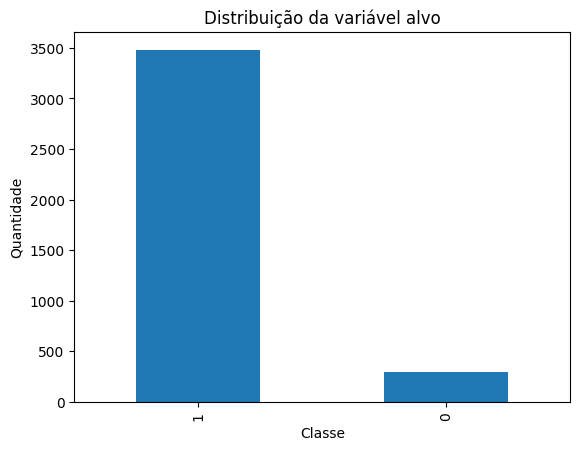

In [16]:
import matplotlib.pyplot as plt

df['binaryClass'].value_counts().plot(kind='bar')
plt.title('Distribuição da variável alvo')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

<Figure size 640x480 with 0 Axes>

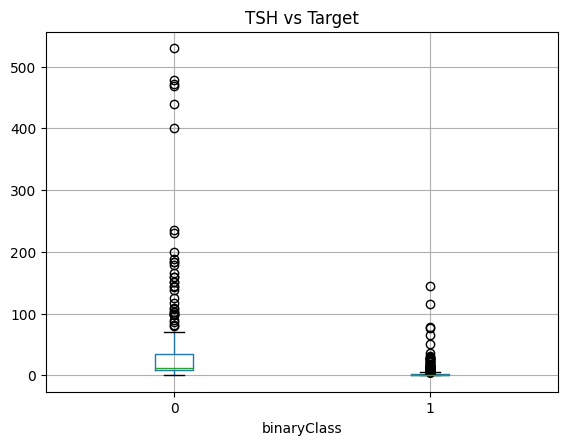

<Figure size 640x480 with 0 Axes>

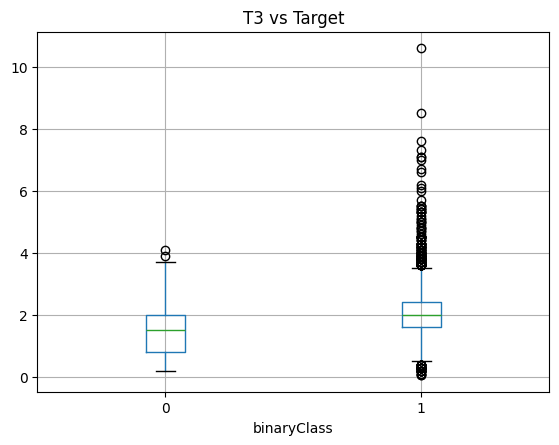

<Figure size 640x480 with 0 Axes>

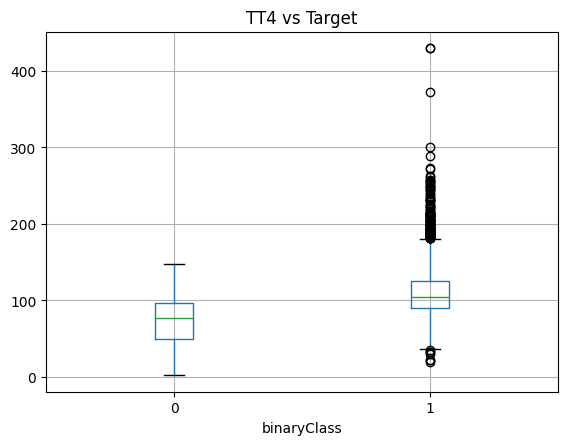

<Figure size 640x480 with 0 Axes>

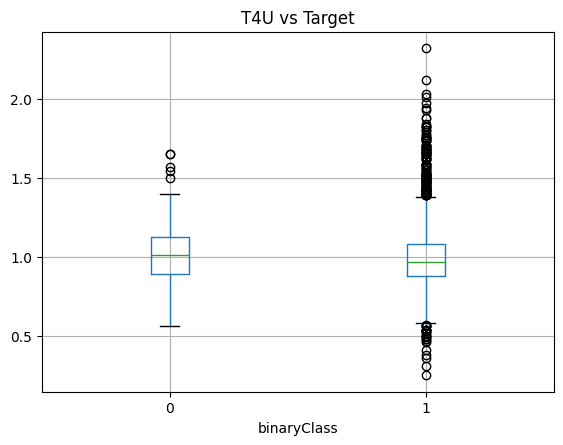

<Figure size 640x480 with 0 Axes>

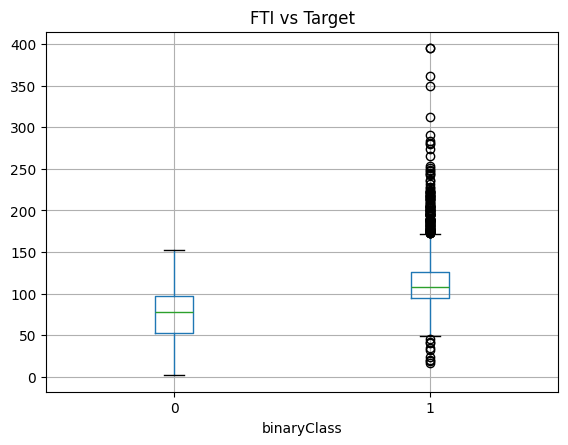

In [17]:
for col in ['TSH', 'T3', 'TT4', 'T4U', 'FTI']:
    plt.figure()
    df.boxplot(column=col, by='binaryClass')
    plt.title(f'{col} vs Target')
    plt.suptitle('')
    plt.show()

**Idade vs target**

<Figure size 640x480 with 0 Axes>

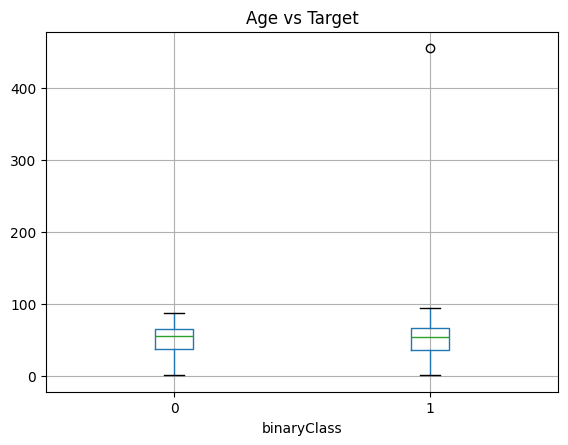

In [18]:
plt.figure()
df.boxplot(column='age', by='binaryClass')
plt.title('Age vs Target')
plt.suptitle('')
plt.show()

**Sexo vs target**

In [19]:
pd.crosstab(df['sex'], df['binaryClass'], normalize='index')

binaryClass,0,1
sex,,
F,0.086694,0.913306
M,0.056918,0.943082


## Análise Exploratória dos Dados (EDA)

A análise exploratória teve como objetivo identificar padrões e relações entre as variáveis preditoras e a variável alvo (`binaryClass`).

### Distribuição da variável alvo

Observa-se um forte desbalanceamento entre as classes, com predominância da classe positiva (~92%). Esse fator será considerado na etapa de modelagem, com uso de métricas apropriadas.

### Variáveis numéricas

#### FTI
A variável FTI apresentou diferença significativa entre as classes, com valores mais elevados associados à classe positiva. Esse comportamento sugere forte relevância dessa variável para o modelo.

#### T4U
A variável T4U apresentou distribuições semelhantes entre as classes, indicando baixo poder discriminativo isolado.

#### Age
A variável idade apresentou pouca diferença entre as classes, sugerindo impacto limitado na predição do alvo.

### Variáveis categóricas

#### Sexo
A análise por sexo mostrou distribuição semelhante entre as classes, com leve predominância da classe positiva em ambos os grupos. Dessa forma, o impacto dessa variável parece limitado.

### Considerações gerais

De forma geral, algumas variáveis laboratoriais demonstram maior capacidade de discriminação, enquanto variáveis demográficas apresentam menor influência isolada. Essas relações serão exploradas na etapa de modelagem.

**Modelagem**

In [20]:
# ============================================================
# 8. Modelos
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Modelo 1 - Regressão Logística
model_lr = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Modelo 2 - Random Forest
model_rf = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Modelo 3 - Gradient Boosting
model_gb = Pipeline([
    ('preprocessing', preprocessor),
    ('model', HistGradientBoostingClassifier(random_state=42))
])

**Treinar os modelos**

In [21]:
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_gb.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'TSH', 'T3', 'TT4',
                                                   'T4U', 'FTI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'referral source...
                                                 ('bin', 'passthrough',
                                                  ['on thyroxine',
                                                   'query on thyroxine',
                                                   'on antithyroid medication',
                                                   'sick', 'pregnant',
                                                   'thyroid surgery',
                                                   'I131 treatment',
                                                   'query hypothyroid',
                                                   'query hyperthyroid',
                                                   'lithium', 'goitre', 'tumor',
                                                   'hypopituitary', 'psych',
                                                   'TSH measured',
                                                   'T3 measured',
                                                   'TT4 measured',
                                                   'T4U measured',
                                                   'FTI measured'])])),
                ('model', HistGradientBoostingClassifier(random_state=42))])

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

def avaliar_modelo(model, X_test, y_test, nome):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f'\n===== {nome} =====')
    print(classification_report(y_test, y_pred))
    print('ROC AUC:', roc_auc_score(y_test, y_proba))

avaliar_modelo(model_lr, X_test, y_test, 'Logistic Regression')
avaliar_modelo(model_rf, X_test, y_test, 'Random Forest')
avaliar_modelo(model_gb, X_test, y_test, 'Gradient Boosting')


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.91      0.53      0.67        58
           1       0.96      1.00      0.98       697

    accuracy                           0.96       755
   macro avg       0.94      0.77      0.83       755
weighted avg       0.96      0.96      0.96       755

ROC AUC: 0.9873596200465047

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      1.00      1.00       697

    accuracy                           1.00       755
   macro avg       0.98      1.00      0.99       755
weighted avg       1.00      1.00      1.00       755

ROC AUC: 0.9995176371642012

===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        58
           1       1.00      1.00      1.00       697

    accuracy                       

## Modelagem e Avaliação

Foram avaliados três modelos de machine learning:

- Regressão Logística
- Random Forest
- Gradient Boosting

### Resultados

A Regressão Logística apresentou bom desempenho geral, porém com menor capacidade de identificar corretamente a classe minoritária, evidenciado por um recall mais baixo para essa classe.

Os modelos baseados em árvores (Random Forest e Gradient Boosting) apresentaram desempenho significativamente superior, com métricas próximas de perfeição, incluindo recall, precisão e ROC AUC.

### Modelo selecionado

O modelo de **Gradient Boosting** foi escolhido como modelo final devido ao seu desempenho superior e maior capacidade de capturar relações não lineares nos dados.

### Considerações

Os resultados extremamente elevados indicam que as variáveis disponíveis possuem alto poder preditivo. No entanto, é importante considerar a possibilidade de sobreajuste ou presença de variáveis altamente correlacionadas com o alvo, sendo recomendável validação adicional em dados externos.

**Feature Importance**

In [24]:
from sklearn.inspection import permutation_importance
import pandas as pd

# calcular importância por permutação
result = permutation_importance(
    model_gb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

feat_imp = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

feat_imp.head(10)

,0
TSH,0.074013
on thyroxine,0.009566
TT4,0.004353
T3,0.002502
thyroid surgery,0.001292
FTI,0.000214
T4U,0.000143
sex,0.000000
query on thyroxine,0.000000
sick,0.000000


### Importância das Variáveis

A análise de importância por permutação revelou que a variável mais relevante para a predição é o TSH, destacando-se significativamente em relação às demais. Esse resultado é consistente com o conhecimento clínico, uma vez que o TSH é o principal indicador da função tireoidiana.

Outras variáveis relevantes incluem indicadores de tratamento (on thyroxine) e exames laboratoriais como TT4 e T3, que complementam a avaliação do estado da tireoide.

Por outro lado, variáveis como sexo e indicadores clínicos genéricos apresentaram impacto praticamente nulo no modelo, sugerindo baixa relevância preditiva.

De forma geral, o modelo baseia suas decisões principalmente em exames laboratoriais, indicando que o problema é altamente dependente dessas medições.

Adicionalmente, o desempenho extremamente elevado do modelo (ROC AUC próximo de 1.0) sugere que o problema pode ser facilmente separável ou que existam variáveis altamente correlacionadas com a variável alvo.

**Validar possível data leakage**

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# usar só TSH
X_tsh = X[['TSH']]
y_tsh = y.copy()

X_train_tsh, X_test_tsh, y_train_tsh, y_test_tsh = train_test_split(
    X_tsh, y_tsh,
    test_size=0.2,
    stratify=y_tsh,
    random_state=42
)

model_tsh = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression())
])

model_tsh.fit(X_train_tsh, y_train_tsh)

y_pred_proba_tsh = model_tsh.predict_proba(X_test_tsh)[:, 1]

roc_auc_score(y_test_tsh, y_pred_proba_tsh)

np.float64(0.9915400979567605)

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

X_sem_tsh = X.drop(columns=['TSH'])

X_train_sem_tsh, X_test_sem_tsh, y_train_sem_tsh, y_test_sem_tsh = train_test_split(
    X_sem_tsh, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model_sem_tsh = Pipeline([
    ('preprocessing', ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), [col for col in num_cols if col != 'TSH']),
        ('cat', cat_pipeline, cat_cols),
        ('bin', 'passthrough', [col for col in X_sem_tsh.columns if col not in [c for c in num_cols if c != 'TSH'] + cat_cols])
    ])),
    ('model', HistGradientBoostingClassifier(random_state=42))
])

model_sem_tsh.fit(X_train_sem_tsh, y_train_sem_tsh)

y_pred_sem_tsh = model_sem_tsh.predict(X_test_sem_tsh)
y_proba_sem_tsh = model_sem_tsh.predict_proba(X_test_sem_tsh)[:, 1]

print(classification_report(y_test_sem_tsh, y_pred_sem_tsh))
print('ROC AUC:', roc_auc_score(y_test_sem_tsh, y_proba_sem_tsh))

              precision    recall  f1-score   support

           0       0.72      0.31      0.43        58
           1       0.95      0.99      0.97       697

    accuracy                           0.94       755
   macro avg       0.83      0.65      0.70       755
weighted avg       0.93      0.94      0.93       755

ROC AUC: 0.8515064562410329


### Avaliação de Robustez do Modelo

Para avaliar a dependência do modelo em relação às variáveis mais relevantes, foram realizados testes adicionais utilizando apenas a variável TSH e, posteriormente, removendo essa variável do conjunto de dados.

Observou-se que, utilizando apenas o TSH, o modelo já alcança um desempenho extremamente elevado (ROC AUC ≈ 0.99), evidenciando o alto poder preditivo dessa variável.

Por outro lado, ao remover o TSH, houve uma queda significativa no desempenho (ROC AUC ≈ 0.85), especialmente na capacidade de identificar corretamente a classe minoritária. Esse resultado indica que o modelo depende fortemente de exames laboratoriais para realizar previsões precisas.

Dessa forma, conclui-se que o problema é altamente influenciado por variáveis clínicas específicas, e que o desempenho elevado do modelo não está relacionado a vazamento de dados, mas sim à presença de variáveis altamente informativas.

**Matriz de Confusão**

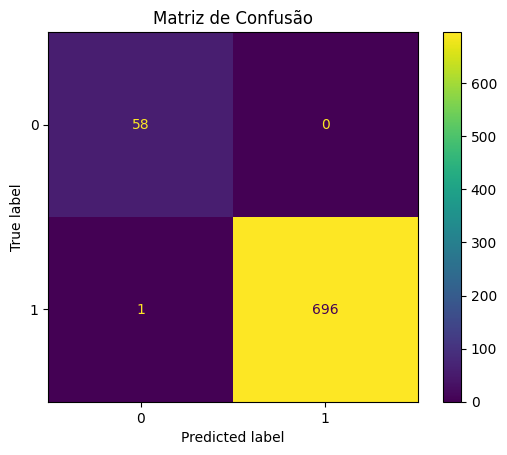

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model_gb,  # ou o melhor modelo
    X_test,
    y_test
)

plt.title("Matriz de Confusão")
plt.show()

**Curva ROC**

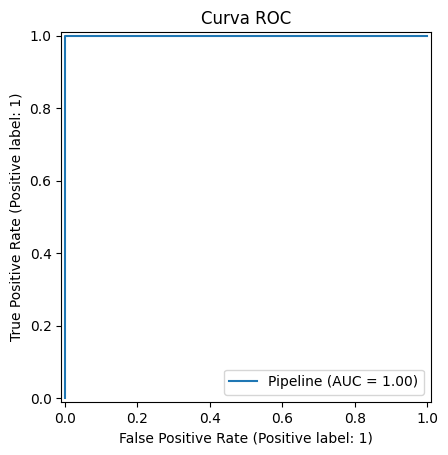

In [29]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    model_gb,
    X_test,
    y_test
)

plt.title("Curva ROC")
plt.show()

**Precision-Recall Curve**

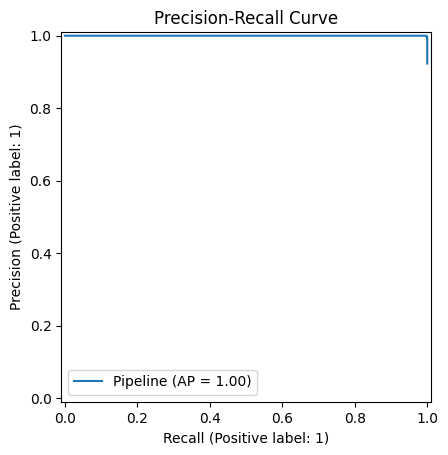

In [30]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    model_gb,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve")
plt.show()

### Avaliação do Modelo

A matriz de confusão demonstra que o modelo apresenta desempenho praticamente perfeito, com apenas um erro de classificação no conjunto de teste. Observa-se ausência de falsos positivos e apenas um falso negativo, indicando alta precisão e sensibilidade.

A curva ROC apresentou AUC igual a 1.0, evidenciando excelente capacidade de separação entre as classes. Da mesma forma, a curva Precision-Recall também atingiu desempenho máximo, mesmo considerando o desbalanceamento do conjunto de dados.

Esses resultados confirmam a alta performance do modelo. No entanto, análises adicionais indicam que esse desempenho está fortemente associado à presença de variáveis altamente informativas, especialmente o TSH, que possui grande poder discriminatório.

Dessa forma, embora o modelo apresente métricas excelentes, é fundamental interpretar os resultados com cautela, considerando a natureza do problema e a influência de variáveis dominantes.